# Time-Aware Advanced Models

## Goal
This notebook extends the existing modeling work using **one split only**: a strict **time-aware holdout**.

Main goals:
1. Build **Feature Set A** = full cleaned numeric set
2. Build **Feature Set B** = correlation-pruned set
3. Build **Feature Set C** = VIF-pruned + manually reduced interpretable set
4. Compare Ridge / Lasso / HistGradientBoosting / RandomForest / ExtraTrees / MLP on the same time-aware split
5. Save run logs, split metadata, plots, and worst-case tables for reporting

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display

from life_expectancy.analysis.diagnostics import (
    group_error_table,
    plot_predicted_vs_actual,
    plot_residual_hist,
    plot_residuals_vs_predicted,
    worst_errors_table,
)
from life_expectancy.data.preprocessing import build_processed_dataset
from life_expectancy.features.feature_selection import (
    build_feature_sets_abc,
    compute_correlation_matrix,
    compute_vif_table,
    save_feature_sets_json,
)
from life_expectancy.modeling.experiments.core import (
    run_time_experiment,
    save_time_split_metadata,
)
from life_expectancy.modeling.model.tree import get_hgb_sweep
from life_expectancy.modeling.registries import get_default_model_registry

In [ ]:
from life_expectancy.data.utils import resolve_project_path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

PROCESSED = resolve_project_path(config, "data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
TARGET = config["features"].get("target_col", "life_expectancy")
YEAR_COL = config["features"].get("year_col", "year")
TEST_YEARS = config.get("modeling", {}).get("split", {}).get("test_years", 3)
RANDOM_STATE = config.get("random_seed", 42)

REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"

REPORT_TABLES.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

RUN_LOG = REPORT_TABLES / "advanced_model_run_log.csv"

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED)
print("Target:", TARGET)

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Processed dir: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/data/processed
Target: life_expectancy


## Load processed data
This notebook works off the processed merged dataset. 

In [4]:
panel, preprocessing_summary = build_processed_dataset(config)

panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="raise").astype(int)

panel.head(), panel.shape

(       country  year      status  life_expectancy_who  adult_mortality  \
 0  Afghanistan  2015  Developing                 65.0            263.0   
 1  Afghanistan  2014  Developing                 59.9            271.0   
 2  Afghanistan  2013  Developing                 59.9            268.0   
 3  Afghanistan  2012  Developing                 59.5            272.0   
 4  Afghanistan  2011  Developing                 59.2            275.0   
 
    infant_deaths  alcohol  percentage_expenditure  hepatitis_b  measles  ...  \
 0             62     0.01               71.279624         65.0      100  ...   
 1             64     0.01               73.523582         62.0      100  ...   
 2             66     0.01               73.219243         64.0      100  ...   
 3             69     0.01               78.184215         67.0      100  ...   
 4             71     0.01                7.097109         68.0      100  ...   
 
            co2  health_expenditure_percent  education_expen

## Build Feature Sets A, B, C
- **A**: full cleaned numeric set
- **B**: correlation-pruned
- **C**: VIF-pruned + manually reduced interpretable set

In [5]:
model_df, feature_sets, feature_meta = build_feature_sets_abc(panel, config)

feature_summary = pd.DataFrame(
    {
        "feature_set": ["A", "B", "C"],
        "n_features": [
            len(feature_sets["A"]),
            len(feature_sets["B"]),
            len(feature_sets["C"]),
        ],
    }
)

display(feature_summary)
feature_sets

,feature_set,n_features
0,A,38
1,B,31
2,C,5


{'A': ['year',
  'adult_mortality',
  'infant_deaths',
  'alcohol',
  'percentage_expenditure',
  'hepatitis_b',
  'measles',
  'bmi',
  'under_five_deaths',
  'polio',
  'total_expenditure',
  'diphtheria',
  'hiv_aids',
  'gdp',
  'population',
  'thinness_1_19_years',
  'thinness_5_9_years',
  'income_composition_of_resources',
  'schooling',
  'undernourishment',
  'co2',
  'health_expenditure_percent',
  'education_expenditure_percent',
  'unemployment',
  'corruption',
  'sanitation',
  'injuries',
  'communicable',
  'noncommunicable_disease',
  'status_flag',
  'gdp_log1p',
  'population_log1p',
  'co2_log1p',
  'gdp_missing_flag',
  'schooling_missing_flag',
  'sanitation_missing_flag',
  'schooling__x__status_flag',
  'gdp_log1p__x__status_flag'],
 'B': ['year',
  'adult_mortality',
  'infant_deaths',
  'alcohol',
  'percentage_expenditure',
  'hepatitis_b',
  'measles',
  'bmi',
  'polio',
  'total_expenditure',
  'diphtheria',
  'hiv_aids',
  'population',
  'thinness_1_19_

In [6]:
save_feature_sets_json(
    feature_sets,
    feature_meta,
    REPORT_TABLES / "feature_sets.json",
)

print("Saved feature sets to:", REPORT_TABLES / "feature_sets.json")

Saved feature sets to: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/reports/tables/feature_sets.json


In [7]:
pd.DataFrame(
    {
        "feature_set": ["A", "B", "C"],
        "n_features": [len(feature_sets["A"]), len(feature_sets["B"]), len(feature_sets["C"])],
    }
)

,feature_set,n_features
0,A,38
1,B,31
2,C,5


## Correlation matrix
This is the main numeric basis for reducing Feature Set A into Feature Set B.

In [8]:
corr_a = compute_correlation_matrix(model_df, feature_sets["A"])
corr_b = compute_correlation_matrix(model_df, feature_sets["B"])

corr_a.to_csv(REPORT_TABLES / "advanced_corr_matrix_A.csv")
corr_b.to_csv(REPORT_TABLES / "advanced_corr_matrix_B.csv")

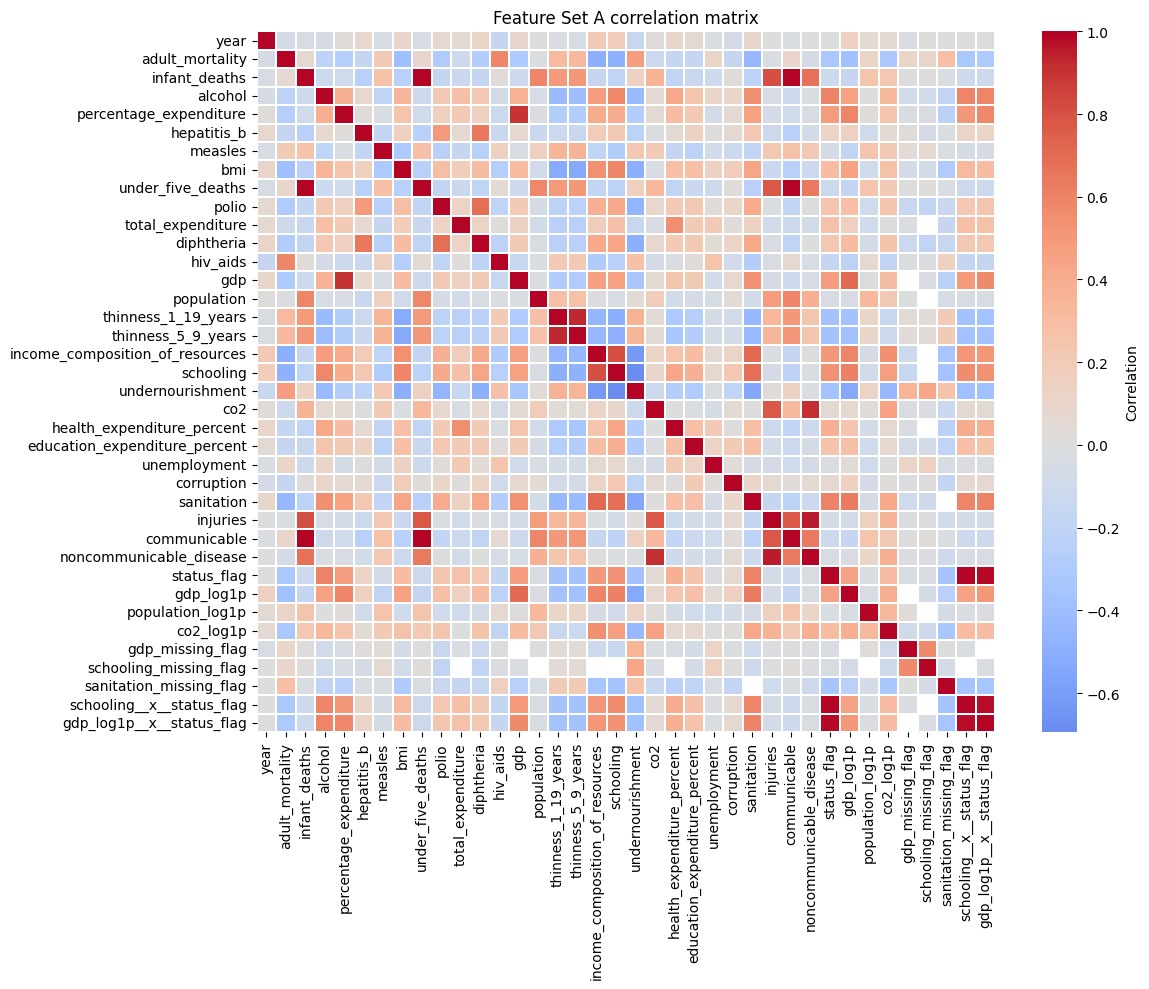

In [9]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_a,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar_kws={"label": "Correlation"},
)

plt.title("Feature Set A correlation matrix")
plt.tight_layout()
plt.savefig(
    REPORT_FIGURES / "advanced_corr_matrix_A.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

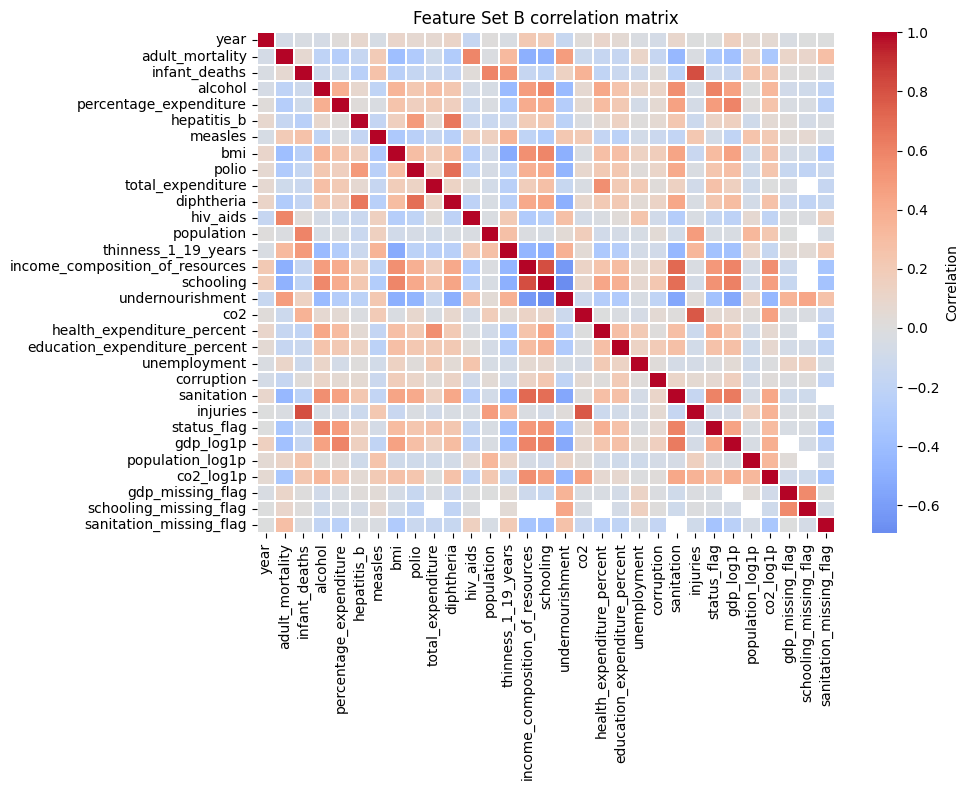

In [10]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_b,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar_kws={"label": "Correlation"},
)

plt.title("Feature Set B correlation matrix")
plt.tight_layout()
plt.savefig(
    REPORT_FIGURES / "advanced_corr_matrix_B.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## VIF check
This is the second reduction step used to move from the correlation-pruned set toward a smaller, more stable set.

In [11]:
vif_b = compute_vif_table(model_df, feature_sets["B"])
vif_c = compute_vif_table(model_df, feature_sets["C"])

vif_b.to_csv(REPORT_TABLES / "advanced_vif_B.csv", index=False)
vif_c.to_csv(REPORT_TABLES / "advanced_vif_C.csv", index=False)

display(vif_b.head(15))
display(vif_c)

,feature,vif
0,year,219.388860
1,corruption,90.329631
2,schooling,64.105797
3,co2_log1p,53.207152
4,population_log1p,45.729032
5,gdp_log1p,40.359481
6,income_composition_of_resources,39.953330
7,diphtheria,34.344853
8,polio,28.056983
9,hepatitis_b,20.157250


,feature,vif
0,status_flag,1.646586
1,year,1.586456
2,percentage_expenditure,1.537446
3,hiv_aids,1.172295
4,infant_deaths,1.080799


## Freeze the time-aware split metadata
We use only the time-aware split in all experiments below and save the metadata once.

In [12]:
registry = get_default_model_registry(random_state=RANDOM_STATE)

tmp_spec = registry["ridge"]

tmp_row, tmp_pred, tmp_split_info, tmp_pipeline = run_time_experiment(
    df=model_df,
    feature_list=feature_sets["C"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="ridge",
    model=tmp_spec["model"],
    scale_numeric=tmp_spec["scale_numeric"],
    test_years=TEST_YEARS,
    run_log_path=None,
    split_label="time_C",
    id_cols=[YEAR_COL],
)

save_time_split_metadata(
    tmp_split_info,
    REPORT_TABLES / "advanced_time_split_metadata.json",
)

tmp_split_info

SplitInfo(split_type='time', n_train=1812, n_test=453, extra={'year_col': 'year', 'test_years': 3, 'max_year': 2015, 'cutoff': 2013, 'test_year_values': [2013, 2014, 2015], 'dropna_target': True})

## HistGradientBoosting sweep

In [13]:
hgb_sweep = get_hgb_sweep(random_state=RANDOM_STATE)

hgb_rows = []
hgb_artifacts = {}

for feature_set_name in ["A", "B", "C"]:
    for model_name, spec in hgb_sweep.items():
        row, pred_df, split_info, pipeline = run_time_experiment(
            df=model_df,
            feature_list=feature_sets[feature_set_name],
            target_col=TARGET,
            year_col=YEAR_COL,
            model_name=model_name,
            model=spec["model"],
            scale_numeric=spec["scale_numeric"],
            test_years=TEST_YEARS,
            run_log_path=RUN_LOG,
            split_label=f"time_{feature_set_name}",
            id_cols=[YEAR_COL],
        )

        row["feature_set"] = feature_set_name
        row["family"] = "HistGBR"

        hgb_rows.append(row)
        hgb_artifacts[(feature_set_name, model_name)] = {
            "pred_df": pred_df,
            "pipeline": pipeline,
            "split_info": split_info,
        }

hgb_results = pd.DataFrame(hgb_rows).sort_values(
    ["feature_set", "rmse", "mae"]
)

hgb_results.to_csv(
    REPORT_TABLES / "advanced_hgbr_sweep.csv",
    index=False,
)

hgb_results

,model_name,split_name,n_train,n_test,rmse,mae,r2,feature_set,family
2,hgb_lr0.05_d5_leaf31,time_A,1812,453,1.521844,1.019459,0.966952,A,HistGBR
4,hgb_lr0.05_dNone_leaf63,time_A,1812,453,1.616782,1.070166,0.962700,A,HistGBR
3,hgb_lr0.1_d3_leaf31,time_A,1812,453,1.648332,1.208859,0.961230,A,HistGBR
1,hgb_lr0.05_d3_leaf31,time_A,1812,453,1.736825,1.292953,0.956955,A,HistGBR
0,hgb_lr0.03_d3_leaf15,time_A,1812,453,1.850278,1.374712,0.951148,A,HistGBR
7,hgb_lr0.05_d5_leaf31,time_B,1812,453,1.525306,1.031561,0.966801,B,HistGBR
9,hgb_lr0.05_dNone_leaf63,time_B,1812,453,1.660644,1.081266,0.960649,B,HistGBR
8,hgb_lr0.1_d3_leaf31,time_B,1812,453,1.740869,1.270981,0.956755,B,HistGBR
6,hgb_lr0.05_d3_leaf31,time_B,1812,453,1.779805,1.317196,0.954799,B,HistGBR
5,hgb_lr0.03_d3_leaf15,time_B,1812,453,1.882685,1.408914,0.949422,B,HistGBR


In [15]:
best_hgb_by_set = (
    hgb_results.loc[hgb_results.groupby("feature_set")["rmse"].idxmin()]
    .sort_values("rmse")
    .reset_index(drop=True)
)

best_hgb_by_set

,model_name,split_name,n_train,n_test,rmse,mae,r2,feature_set,family
0,hgb_lr0.05_d5_leaf31,time_A,1812,453,1.521844,1.019459,0.966952,A,HistGBR
1,hgb_lr0.05_d5_leaf31,time_B,1812,453,1.525306,1.031561,0.966801,B,HistGBR
2,hgb_lr0.05_dNone_leaf63,time_C,1812,453,3.539506,2.761731,0.821231,C,HistGBR


## Full model comparison on A, B, C
Now compare the best boosted-tree configuration against Ridge, Lasso, Random Forest, Extra Trees, and MLP.

In [16]:
registry = get_default_model_registry(random_state=RANDOM_STATE)

comparison_rows = []
comparison_artifacts = {}

model_name_map = {
    "ridge": "RidgeCV",
    "lasso": "LassoCV",
    "rf": "RandomForest",
    "extra_trees": "ExtraTrees",
    "mlp": "MLP",
}

for feature_set_name in ["A", "B", "C"]:
    best_hgb_name = best_hgb_by_set.loc[
        best_hgb_by_set["feature_set"] == feature_set_name,
        "model_name",
    ].iloc[0]
    best_hgb_spec = hgb_sweep[best_hgb_name]

    local_registry = {
        "RidgeCV": registry["ridge"],
        "LassoCV": registry["lasso"],
        "HistGBR_best": best_hgb_spec,
        "RandomForest": registry["rf"],
        "ExtraTrees": registry["extra_trees"],
        "MLP": registry["mlp"],
    }

    for model_name, spec in local_registry.items():
        row, pred_df, split_info, pipeline = run_time_experiment(
            df=model_df,
            feature_list=feature_sets[feature_set_name],
            target_col=TARGET,
            year_col=YEAR_COL,
            model_name=model_name,
            model=spec["model"],
            scale_numeric=spec["scale_numeric"],
            test_years=TEST_YEARS,
            run_log_path=RUN_LOG,
            split_label=f"time_{feature_set_name}",
            id_cols=[YEAR_COL],
        )

        row["feature_set"] = feature_set_name

        comparison_rows.append(row)
        comparison_artifacts[(feature_set_name, model_name)] = {
            "pred_df": pred_df,
            "pipeline": pipeline,
            "split_info": split_info,
        }

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["feature_set", "rmse", "mae"]
)

comparison_df.to_csv(
    REPORT_TABLES / "advanced_model_comparison.csv",
    index=False,
)

comparison_df

,model_name,split_name,n_train,n_test,rmse,mae,r2,feature_set
2,HistGBR_best,time_A,1812,453,1.521844,1.019459,0.966952,A
3,RandomForest,time_A,1812,453,1.537577,1.147759,0.966265,A
4,ExtraTrees,time_A,1812,453,1.669366,1.272101,0.960234,A
1,LassoCV,time_A,1812,453,3.093671,2.454510,0.863430,A
0,RidgeCV,time_A,1812,453,3.152573,2.503920,0.858180,A
5,MLP,time_A,1812,453,3.243162,2.547115,0.849913,A
8,HistGBR_best,time_B,1812,453,1.525306,1.031561,0.966801,B
9,RandomForest,time_B,1812,453,1.595402,1.201052,0.963680,B
10,ExtraTrees,time_B,1812,453,1.729748,1.326776,0.957306,B
7,LassoCV,time_B,1812,453,3.107600,2.462052,0.862198,B


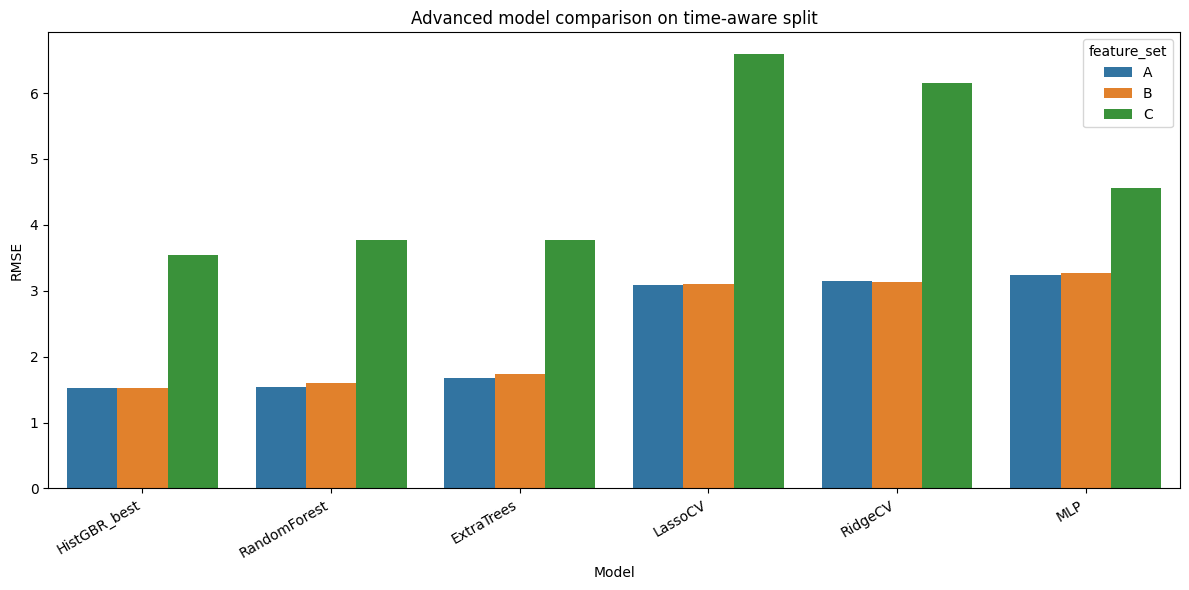

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_df,
    x="model_name",
    y="rmse",
    hue="feature_set",
)

plt.title("Advanced model comparison on time-aware split")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    REPORT_FIGURES / "advanced_model_comparison_rmse.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Diagnostics for the best boosted model

These figures/tables support later reporting:
- predicted vs actual
- residuals vs predicted
- error histogram
- top 10 worst predictions
- MAE by region
- MAE by year

In [19]:
best_boosted_row = (
    comparison_df[comparison_df["model_name"] == "HistGBR_best"]
    .sort_values(["rmse", "mae", "r2"], ascending=[True, True, False])
    .iloc[0]
)

best_boosted_row

model_name     HistGBR_best
split_name           time_A
n_train                1812
n_test                  453
rmse               1.521844
mae                1.019459
r2                 0.966952
feature_set               A
Name: 2, dtype: object

In [20]:
best_fs = best_boosted_row["feature_set"]

best_pred_df = comparison_artifacts[(best_fs, "HistGBR_best")]["pred_df"]

worst10 = worst_errors_table(best_pred_df, n=10)
mae_by_year = group_error_table(best_pred_df, group_col=YEAR_COL)

worst10.to_csv(
    REPORT_TABLES / "advanced_best_boosted_worst10.csv",
    index=False,
)

mae_by_year.to_csv(
    REPORT_TABLES / "advanced_best_boosted_mae_by_year.csv",
    index=False,
)

display(worst10)
display(mae_by_year)

,year,y_true,y_pred,error,abs_error
0,2014,50.236000,58.774579,8.538579,8.538579
1,2015,51.970500,60.122813,8.152313,8.152313
2,2015,59.909500,66.400241,6.490741,6.490741
3,2015,55.460000,61.100836,5.640836,5.640836
4,2013,65.049500,59.451872,-5.597628,5.597628
5,2015,62.992500,68.124373,5.131873,5.131873
6,2013,63.440500,58.754738,-4.685762,4.685762
7,2015,61.215500,65.898258,4.682758,4.682758
8,2015,63.267000,58.723435,-4.543565,4.543565
9,2014,85.060976,80.587698,-4.473278,4.473278


,year,n,mae,rmse
0,2015,151,1.159764,1.724260
1,2014,151,1.030514,1.532118
2,2013,151,0.868098,1.275763


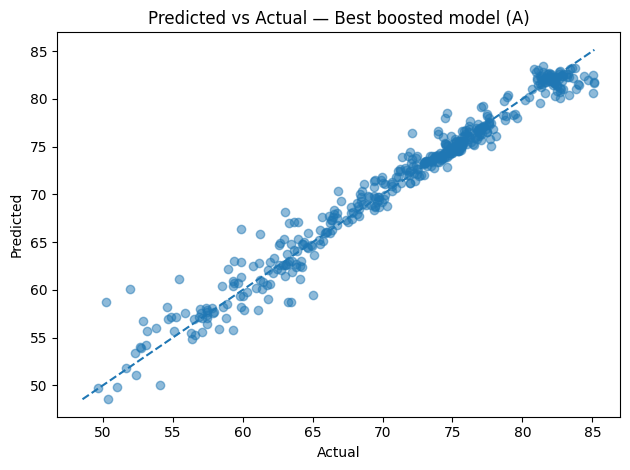

In [21]:
ax = plot_predicted_vs_actual(
    best_pred_df["y_true"],
    best_pred_df["y_pred"],
    title=f"Predicted vs Actual — Best boosted model ({best_fs})",
)

plt.tight_layout()
plt.savefig(
    REPORT_FIGURES / "advanced_best_boosted_pred_vs_actual.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

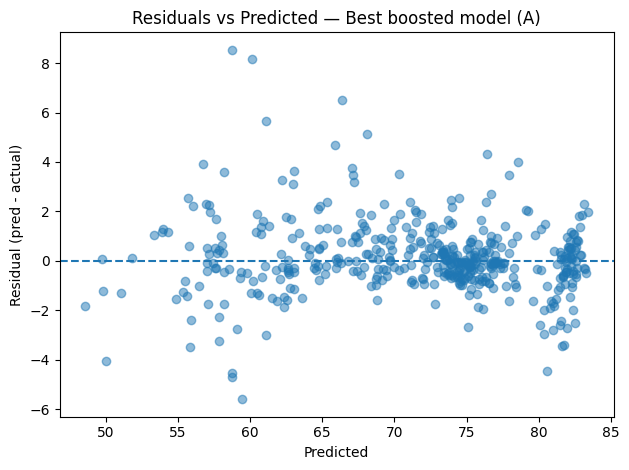

In [22]:
ax = plot_residuals_vs_predicted(
    best_pred_df["y_true"],
    best_pred_df["y_pred"],
    title=f"Residuals vs Predicted — Best boosted model ({best_fs})",
)

plt.tight_layout()
plt.savefig(
    REPORT_FIGURES / "advanced_best_boosted_residuals_vs_pred.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

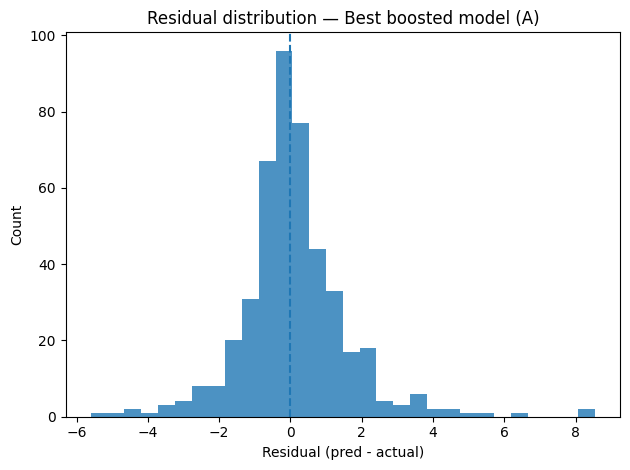

In [23]:
ax = plot_residual_hist(
    best_pred_df["y_true"],
    best_pred_df["y_pred"],
    title=f"Residual distribution — Best boosted model ({best_fs})",
)

plt.tight_layout()
plt.savefig(
    REPORT_FIGURES / "advanced_best_boosted_residual_hist.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()